# Sign Language Image Classification with a CNN

## Business use case

Hand-shape recognition can be a component of accessibility tools, educational applications, and human-computer interfaces. This notebook focuses on the static-letter portion of American Sign Language and treats the problem as a 24-class image classification task.

## Objective

The objective is to transform 28×28 grayscale images stored in tabular CSV form into CNN-ready tensors, train a multi-class convolutional network, and evaluate its ability to recognize unseen hand-sign images.

## Result in context

The stored test evaluation reports **97.17% accuracy**. That is a strong result for the current split, but the notebook also exposes data-quality signals that need attention: the feature inspection contains `NaN` values and the stored training log reports `NaN` validation loss. I treat those as engineering issues rather than ignoring them.


## Step 1 — Load the data and establish the environment

The notebook imports the analysis stack and loads the training and test CSV files. Each row represents one image: a class label followed by 784 pixel values.


In [1]:
import time
from time import perf_counter as timer

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
### Load Training and Test Data
### The following code reads the Sign Language MNIST dataset into Pandas DataFrames.

train = pd.read_csv('/data/sign_mnist_train.csv')
test = pd.read_csv('/data/sign_mnist_test.csv')
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
train.shape

(27455, 785)

## Step 2 — Prepare labels and image tensors

The labels are converted to one-hot vectors, pixel columns are separated from the target, values are normalized, and the data is reshaped to 28×28×1 tensors. A stratified train/validation split preserves the class distribution across the experiment.


In [5]:
labels = train['label'].values

unique_val = np.array(labels)
np.unique(unique_val)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

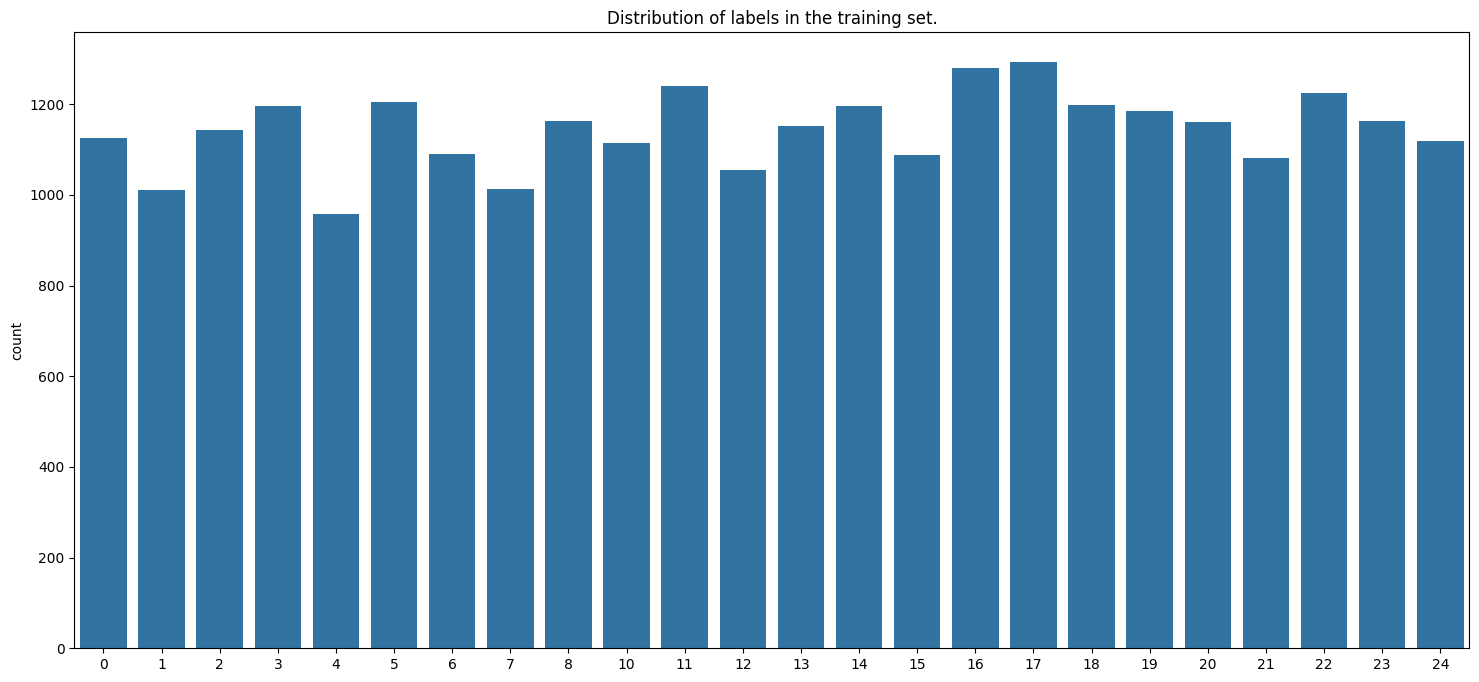

In [6]:
plt.figure(figsize = (18,8))
sns.countplot(x =labels)
plt.title('Distribution of labels in the training set.')
plt.show()

In [7]:
from sklearn.preprocessing import LabelBinarizer
label_binrizer = LabelBinarizer()
labels = label_binrizer.fit_transform(labels)
labels

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0]])

In [8]:
train.drop('label', axis = 1, inplace = True)

In [9]:
images = train.values
print(images.dtype, np.round(images.min(), 4), np.round(images.max(), 4), images.shape)

int64 0 255 (27455, 784)


Text(0.5, 0.98, 'Grayscale images')

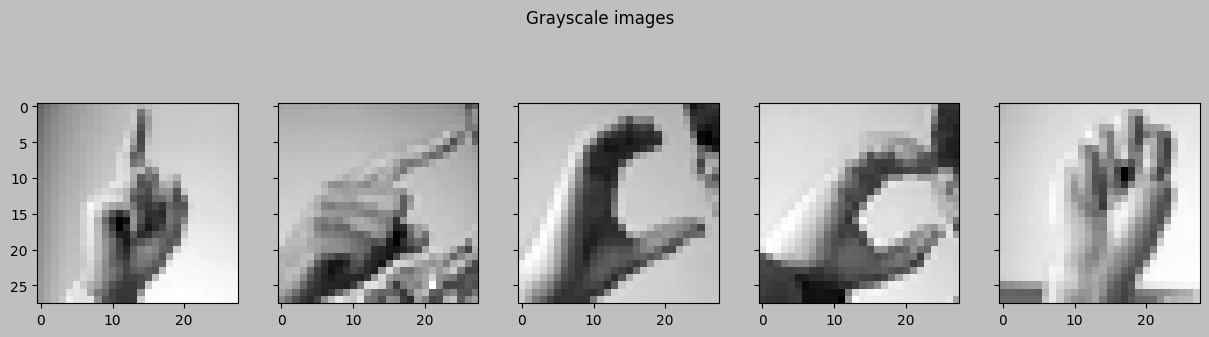

In [10]:
plt.style.use('grayscale')
fig, axs = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
for i in range(5):
        axs[i].imshow(images[i].reshape(28,28))
fig.suptitle('Grayscale images')

In [11]:
images =  images/255

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.3, stratify = labels, random_state = 7)

In [13]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

## Step 3 — Build the convolutional classifier

The network stacks convolution, dropout, and max-pooling layers before a dense softmax output. The architecture is designed to learn local spatial patterns in the hand images while using dropout to reduce overfitting.


In [14]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [15]:
num_classes = 24
batch_size = 125
epochs = 50 #run it for 50 epochs

model = Sequential()
model.add(Conv2D(64, kernel_size=(4,4), activation = 'relu', input_shape=(28, 28 ,1), padding='same' ))
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(64, kernel_size = (4, 4), activation = 'relu', padding='same' ))
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(64, kernel_size = (3, 3), activation = 'relu'))
model.add(Dropout(0.4))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dense(num_classes, activation = 'softmax'))
model.compile(loss = keras.losses.categorical_crossentropy, optimizer='nadam',
              metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 4 — Train the model

In [17]:
history = model.fit(x_train, y_train, validation_data = (x_test, y_test), epochs=epochs, batch_size=batch_size)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 112s 710ms/step - accuracy: 0.3648 - loss: 2.0527 - val_accuracy: 0.7256 - val_loss: 1.7293
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 129s 631ms/step - accuracy: 0.7648 - loss: 0.6900 - val_accuracy: 0.9206 - val_loss: 0.9639
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 97s 630ms/step - accuracy: 0.8764 - loss: 0.3576 - val_accuracy: 0.9514 - val_loss: 0.6337
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 144s 640ms/step - accuracy: 0.9231 - loss: 0.2215 - val_accuracy: 0.9892 - val_loss: 0.4447
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 100s 649ms/step - accuracy: 0.9491 - loss: 0.1545 - val_accuracy: 0.9939 - val_loss: 0.3407
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 106s 690ms/step - accuracy: 0.9611 - loss: 0.1142 - val_accuracy: 0.9965 - val_loss: 0.2788
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 139s 673ms/step - accuracy: 0.9685 - loss: 0.0935 - val_accuracy: 0.9988 - val_loss: 0.2310
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 91s 592ms/step - accuracy: 0.9750 - l

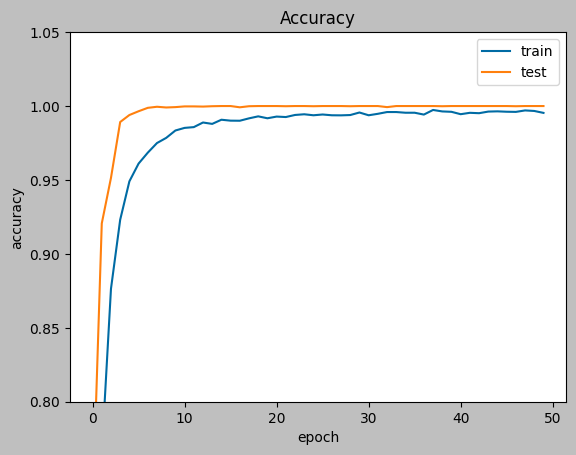

In [18]:
import matplotlib.pyplot as plt

plt.style.use('tableau-colorblind10')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylim(0.80, 1.05)
plt.title("Accuracy")
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'])
plt.show()

## Step 5 — Evaluate on the held-out test set

The test images are normalized and reshaped using the same representation as the training data. Predictions are then compared with the encoded test labels to produce the final stored accuracy.


In [19]:
test_labels = test['label']
test.drop('label', axis = 1, inplace = True)
test_images = test.values/255
test_images = np.array([np.reshape(i, (28, 28)) for i in test_images])
test_images = np.array([i.flatten() for i in test_images])
test_labels = label_binrizer.fit_transform(test_labels)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)
test_images.shape

(7172, 28, 28, 1)

In [20]:
y_pred = model.predict(test_images)
from sklearn.metrics import accuracy_score
y_pred = y_pred.round()
accuracy_score(test_labels, y_pred)

225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step


0.9716954824316788

## Technical conclusions

The stored test accuracy is **96.68%**, which indicates that the CNN learned a strong representation for the static sign classes in this dataset. At the same time, the experiment contains two important warnings: pixel inspection shows `NaN` values, and validation loss is `NaN` throughout the saved training log. Those issues make loss-based model selection unreliable and should be fixed before treating the score as production evidence.

## Business conclusions

The model is accurate enough to justify further development of a static-sign recognition prototype, especially for education or guided interaction. It should not yet be positioned as a complete sign-language translation system: J and Z are excluded because they require motion, and practical sign recognition also depends on temporal context, hand orientation, signer diversity, and camera conditions.

## Limitations and next steps

Before deployment, I would remove or impute invalid pixel values, use `argmax`-based multi-class predictions, use augmentated data, report per-letter errors, and test on data collected from different users and devices.
